# 第 2 题：多层感知机 (MLP)

## 2.1 理论计算题

### 1. 非线性激活函数的重要性：
**证明：**
假设输入为 $x$，隐藏层没有激活函数，即：
$$h = W_1 x + b_1$$
输出层为：
$$o = W_2 h + b_2$$

将 $h$ 的表达式代入输出层方程中：
$$o = W_2 (W_1 x + b_1) + b_2$$
$$o = W_2 W_1 x + W_2 b_1 + b_2$$

由于矩阵乘法满足结合律，我们可以定义新的权重矩阵 $W'$ 和偏置向量 $b'$：
$$W' = W_2 W_1$$
$$b' = W_2 b_1 + b_2$$

则输出层方程可以简写为：
$$o = W' x + b'$$

**结论：** 经过代数推导，没有非线性激活函数的多层感知机等价于一个单层神经网络（即纯线性变换）。等价后的权重矩阵为 $W' = W_2 W_1$，偏置向量为 $b' = W_2 b_1 + b_2$。这说明如果没有非线性激活函数，无论增加多少隐藏层，神经网络依然只能表达线性映射，无法拟合复杂的非线性函数。

---

### 2. 激活函数性质分析：

**(1) Sigmoid 函数：**
**数学表达式：**
$$\text{Sigmoid}(x) = \sigma(x) = \frac{1}{1 + e^{-x}}$$

**导数推导：**
$$\sigma'(x) = \left( \frac{1}{1 + e^{-x}} \right)' = \frac{-1}{(1 + e^{-x})^2} \cdot (-e^{-x}) = \frac{e^{-x}}{(1 + e^{-x})^2}$$
将其拆分并与原函数联系起来：
$$\sigma'(x) = \frac{1}{1 + e^{-x}} \cdot \frac{e^{-x}}{1 + e^{-x}} = \sigma(x) \left( \frac{1 + e^{-x} - 1}{1 + e^{-x}} \right) = \sigma(x)(1 - \sigma(x))$$

**导数与函数自身的关系：**
$$\text{Sigmoid}'(x) = \text{Sigmoid}(x)(1 - \text{Sigmoid}(x))$$

**(2) tanh 函数：**
**数学表达式：**
$$\text{tanh}(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$$

**导数推导：**
$$\text{tanh}'(x) = \left( \frac{e^x - e^{-x}}{e^x + e^{-x}} \right)' = \frac{(e^x + e^{-x})(e^x + e^{-x}) - (e^x - e^{-x})(e^x - e^{-x})}{(e^x + e^{-x})^2}$$
$$\text{tanh}'(x) = \frac{(e^x + e^{-x})^2 - (e^x - e^{-x})^2}{(e^x + e^{-x})^2} = 1 - \left( \frac{e^x - e^{-x}}{e^x + e^{-x}} \right)^2 = 1 - \text{tanh}^2(x)$$

**导数与函数自身的关系：**
$$\text{tanh}'(x) = 1 - \text{tanh}^2(x)$$



## 2.2 编程题
不使用深度学习框架的高级 API（仅使用 Tensor 基础算子如 `torch.matmul` 等），从零实现一个多分类的单隐藏层 MLP。


In [3]:
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader

# ==========================================
# 准备 Fashion-MNIST 数据集
# ==========================================
batch_size = 256
transform = transforms.ToTensor() # 将图像转换为 Tensor 并归一化到 [0, 1]

train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, transform=transform, download=True)

train_iter = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_iter = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# ==========================================
# 1. 手动初始化隐藏层参数和输出层参数
# ==========================================
num_inputs, num_outputs, num_hiddens = 784, 10, 256

# 提示：使用正态分布随机初始化
W1 = torch.normal(0, 0.01, size=(num_inputs, num_hiddens), requires_grad=True)
b1 = torch.zeros(num_hiddens, requires_grad=True)
W2 = torch.normal(0, 0.01, size=(num_hiddens, num_outputs), requires_grad=True)
b2 = torch.zeros(num_outputs, requires_grad=True)

params = [W1, b1, W2, b2]

# ==========================================
# 2. 实现 ReLU 激活函数的前向传播：max(0, x)
# ==========================================
def relu(X):
    # 仅使用 Tensor 基础算子
    a = torch.zeros_like(X)
    return torch.max(X, a)

# 定义单隐藏层 MLP 模型
def net(X):
    # 展平输入图像，从 (batch_size, 1, 28, 28) 变为 (batch_size, 784)
    X = X.reshape((-1, num_inputs))
    # 隐藏层：线性变换 + ReLU 激活
    H = relu(torch.matmul(X, W1) + b1)
    # 输出层：线性变换
    return torch.matmul(H, W2) + b2

# ==========================================
# 3. 实现带有 Softmax 的交叉熵损失函数
# ==========================================
def cross_entropy(y_hat, y):
    # 减去每行的最大值防止计算 exp 时数值爆炸
    y_hat_max, _ = torch.max(y_hat, dim=1, keepdim=True)
    y_hat_exp = torch.exp(y_hat - y_hat_max)
    partition = y_hat_exp.sum(dim=1, keepdim=True)
    
    # 计算 log softmax
    log_softmax = y_hat - y_hat_max - torch.log(partition)
    
    # 根据真实标签 y，提取对应的负对数概率
    return -log_softmax[range(len(y_hat)), y]

# ==========================================
# 4. 编写训练循环，通过 Mini-batch SGD 手动更新参数
# ==========================================
def sgd(params, lr, batch_size):
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

num_epochs = 10
lr = 0.1

print("开始训练...")
for epoch in range(num_epochs):
    train_l_sum, train_acc_sum, n = 0.0, 0.0, 0
    for X, y in train_iter:
        # 1. 前向传播
        y_hat = net(X)
        
        # 2. 计算损失 (交叉熵返回的是一个向量，求和以方便计算梯度)
        l = cross_entropy(y_hat, y).sum()
        
        # 3. 反向传播计算梯度
        l.backward()
        
        # 4. 参数更新 (SGD)
        sgd(params, lr, batch_size)
        
        # 记录指标
        train_l_sum += l.item()
        train_acc_sum += (y_hat.argmax(dim=1) == y).sum().item()
        n += y.numel()
    
    epoch_loss = train_l_sum / n
    epoch_acc = train_acc_sum / n
    print(f"Epoch {epoch + 1:02d}: Loss = {epoch_loss:.4f}, Accuracy = {epoch_acc:.4f}")

# --- 测试模型在测试集上的表现 ---
def evaluate_accuracy(net, data_iter):
    acc_sum, n = 0.0, 0
    with torch.no_grad():
        for X, y in data_iter:
            acc_sum += (net(X).argmax(dim=1) == y).sum().item()
            n += y.numel()
    return acc_sum / n

test_acc = evaluate_accuracy(net, test_iter)
print(f"\n训练完成！最终测试集准确率: {test_acc:.4f}")


开始训练...
Epoch 01: Loss = 1.0417, Accuracy = 0.6350
Epoch 02: Loss = 0.6027, Accuracy = 0.7881
Epoch 03: Loss = 0.5222, Accuracy = 0.8178
Epoch 04: Loss = 0.4833, Accuracy = 0.8310
Epoch 05: Loss = 0.4524, Accuracy = 0.8417
Epoch 06: Loss = 0.4344, Accuracy = 0.8473
Epoch 07: Loss = 0.4177, Accuracy = 0.8521
Epoch 08: Loss = 0.4061, Accuracy = 0.8571
Epoch 09: Loss = 0.3944, Accuracy = 0.8602
Epoch 10: Loss = 0.3844, Accuracy = 0.8646

训练完成！最终测试集准确率: 0.8501


## 3.1 理论计算题

### 1. 过拟合与欠拟合：
**训练误差（Training Error）与泛化误差（Generalization Error）的区别：**
*   **训练误差**：模型在用于训练的数据集上计算得到的误差。它衡量的是模型对已知数据的拟合程度。
*   **泛化误差**：模型在从未见过的测试数据（或底层数据真实分布）上表现出的期望误差。它衡量的是模型对未知数据的预测能力。

**模型状态：**
当一个模型的训练误差极低，但泛化误差很高时，模型处于**过拟合（Overfitting）**状态。这意味着模型不仅学习到了训练数据中的普遍规律，还把训练数据中的噪声和偶然特征当成了普遍规律，导致其在面对新数据时表现糟糕。

**缓解现象（控制模型复杂度）：**
为了缓解过拟合，需要降低模型的复杂度，常见的方法包括：
1.  **减少模型参数**：例如减少神经网络的层数或每层的神经元个数。
2.  **权重衰减（L2 正则化）**：限制模型参数的取值范围，使权重值偏向于接近 0，从而平滑模型。
3.  **Dropout（暂退法）**：在训练过程中随机使一部分神经元失活，防止模型对某些特定特征的过度依赖。
4.  **提前停止（Early Stopping）**：在验证误差开始上升时停止训练，避免模型过度拟合训练集。

---

### 2. K 折交叉验证：
**具体实施算法步骤：**
1.  **数据划分**：将原始的训练数据集随机且均匀地划分为 $K$ 个互不相交的子集（折，Fold）。
2.  **迭代训练与验证**：进行 $K$ 次迭代（$i = 1, 2, \dots, K$）：
    *   在第 $i$ 次迭代中，将第 $i$ 个子集作为**验证集**（Validation Set）。
    *   将剩余的 $K-1$ 个子集合并起来作为**训练集**（Training Set）。
    *   在训练集上训练模型，并在验证集上计算并记录误差（或准确率等性能指标）。
3.  **性能估计**：计算这 $K$ 次迭代中验证集上记录的性能指标的**平均值**，作为该模型在当前超参数配置下的泛化性能估计。
4.  **模型选择**：使用不同超参数配置重复上述步骤，选择平均性能最好的超参数组合。选定超参数后，通常使用**全部原始训练数据**重新训练最终的模型。



## 3.2 编程题
在你实现的 MLP 上，加入 L2 正则化和 Dropout 机制。


开始训练对比模型...
训练模型 1/3: 无正则化...
训练模型 2/3: 加入权重衰减...
训练模型 3/3: 加入 Dropout...


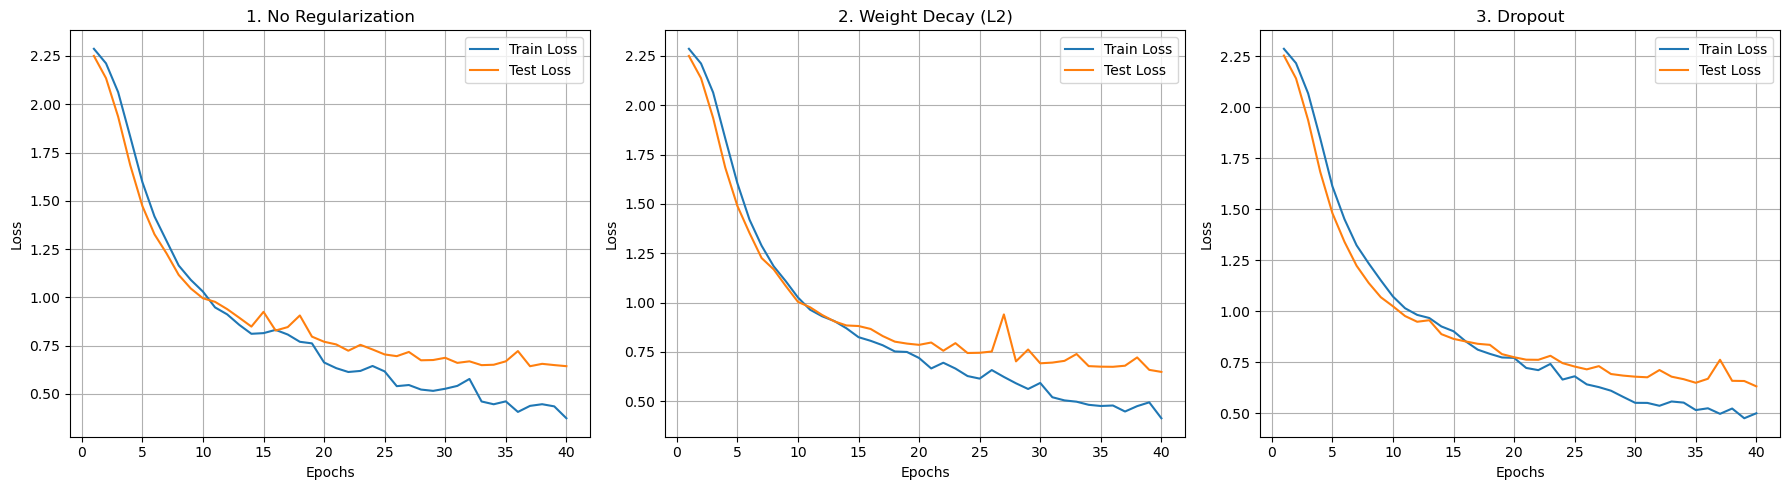

In [4]:
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt

# ==========================================
# 准备极少样本的数据集以制造过拟合
# ==========================================
batch_size = 64
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.FashionMNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, transform=transform, download=True)

# 仅使用前 500 个样本作为训练集来故意制造过拟合
train_subset = Subset(train_dataset, range(500))
train_iter = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
# 测试集可以保持一定数量，这里用前 2000 个加速测试
test_subset = Subset(test_dataset, range(2000))
test_iter = DataLoader(test_subset, batch_size=batch_size, shuffle=False)

num_inputs, num_outputs, num_hiddens = 784, 10, 256

# ==========================================
# 1. & 2. 实现带有权重衰减的 SGD 和 Dropout
# ==========================================

# 1. 权重衰减：修改 SGD
def sgd_weight_decay(params, lr, batch_size, weight_decay):
    with torch.no_grad():
        for param in params:
            # 权重衰减：旧权重乘以 (1 - lr * weight_decay)
            param -= lr * weight_decay * param
            # 正常的梯度下降更新
            param -= lr * param.grad / batch_size
            param.grad.zero_()

# 2. Dropout 从零实现
def dropout_layer(X, dropout, is_training=True):
    assert 0 <= dropout <= 1
    # 在测试时不触发 Dropout
    if not is_training or dropout == 0:
        return X
    # 如果 dropout 率为 1，全部清零
    if dropout == 1:
        return torch.zeros_like(X)
    
    # 随机生成掩码 Mask
    mask = (torch.rand(X.shape) > dropout).float()
    # 缩放以保持期望值不变
    return mask * X / (1.0 - dropout)

# ==========================================
# 定义复杂的 MLP 结构 (引入 Dropout)
# ==========================================
def relu(X):
    return torch.max(X, torch.zeros_like(X))

def cross_entropy(y_hat, y):
    y_hat_max, _ = torch.max(y_hat, dim=1, keepdim=True)
    y_hat_exp = torch.exp(y_hat - y_hat_max)
    partition = y_hat_exp.sum(dim=1, keepdim=True)
    log_softmax = y_hat - y_hat_max - torch.log(partition)
    return -log_softmax[range(len(y_hat)), y]

# 初始化参数的辅助函数
def init_params():
    W1 = torch.normal(0, 0.01, size=(num_inputs, num_hiddens), requires_grad=True)
    b1 = torch.zeros(num_hiddens, requires_grad=True)
    W2 = torch.normal(0, 0.01, size=(num_hiddens, num_outputs), requires_grad=True)
    b2 = torch.zeros(num_outputs, requires_grad=True)
    return [W1, b1, W2, b2]

# 前向传播函数
def net(X, params, dropout_rate, is_training=True):
    W1, b1, W2, b2 = params
    X = X.reshape((-1, num_inputs))
    # 第一层：线性 -> ReLU -> Dropout
    H1 = relu(torch.matmul(X, W1) + b1)
    H1 = dropout_layer(H1, dropout_rate, is_training)
    # 输出层
    return torch.matmul(H1, W2) + b2

# 评估函数 (包含 Loss)
def evaluate_loss(params, data_iter, dropout_rate):
    loss_sum, n = 0.0, 0
    with torch.no_grad():
        for X, y in data_iter:
            y_hat = net(X, params, dropout_rate, is_training=False) # 测试时关闭 Dropout
            loss_sum += cross_entropy(y_hat, y).sum().item()
            n += y.numel()
    return loss_sum / n

# ==========================================
# 3. 对比实验
# ==========================================
def train_model(weight_decay, dropout_rate, num_epochs=30, lr=0.1):
    params = init_params()
    train_losses = []
    test_losses = []
    
    for epoch in range(num_epochs):
        train_l_sum, n = 0.0, 0
        for X, y in train_iter:
            # 训练模式，开启 Dropout
            y_hat = net(X, params, dropout_rate, is_training=True)
            l = cross_entropy(y_hat, y).sum()
            
            l.backward()
            # 只有权重 (W1, W2) 需要进行衰减，偏置 (b1, b2) 通常不衰减
            with torch.no_grad():
                for i, param in enumerate(params):
                    # params: [W1, b1, W2, b2], 索引 0 和 2 是权重
                    decay = weight_decay if i % 2 == 0 else 0.0
                    param -= lr * decay * param
                    param -= lr * param.grad / batch_size
                    param.grad.zero_()
                    
            train_l_sum += l.item()
            n += y.numel()
            
        train_loss = train_l_sum / n
        test_loss = evaluate_loss(params, test_iter, dropout_rate)
        
        train_losses.append(train_loss)
        test_losses.append(test_loss)
        
    return train_losses, test_losses

print("开始训练对比模型...")
num_epochs = 40
lr = 0.1

# 模型1：无正则化 (容易过拟合)
print("训练模型 1/3: 无正则化...")
train_loss_base, test_loss_base = train_model(weight_decay=0.0, dropout_rate=0.0, num_epochs=num_epochs, lr=lr)

# 模型2：有权重衰减 (L2正则化)
print("训练模型 2/3: 加入权重衰减...")
train_loss_wd, test_loss_wd = train_model(weight_decay=0.01, dropout_rate=0.0, num_epochs=num_epochs, lr=lr)

# 模型3：有 Dropout
print("训练模型 3/3: 加入 Dropout...")
train_loss_do, test_loss_do = train_model(weight_decay=0.0, dropout_rate=0.5, num_epochs=num_epochs, lr=lr)

# ==========================================
# 绘制误差曲线对比图
# ==========================================
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(18, 5))

# 1) 无正则化
plt.subplot(1, 3, 1)
plt.plot(epochs, train_loss_base, label='Train Loss')
plt.plot(epochs, test_loss_base, label='Test Loss')
plt.title('1. No Regularization')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# 2) 权重衰减
plt.subplot(1, 3, 2)
plt.plot(epochs, train_loss_wd, label='Train Loss')
plt.plot(epochs, test_loss_wd, label='Test Loss')
plt.title('2. Weight Decay (L2)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# 3) Dropout
plt.subplot(1, 3, 3)
plt.plot(epochs, train_loss_do, label='Train Loss')
plt.plot(epochs, test_loss_do, label='Test Loss')
plt.title('3. Dropout')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


## 4.1 理论计算题

### 1. 梯度消失与梯度爆炸的量化分析：
在 $d$ 层深层神经网络中，反向传播计算梯度时，根据链式法则，会涉及多层雅可比矩阵的连乘项：$\prod_{i=t}^{d-1} \frac{\partial h_{i+1}}{\partial h_i}$。
对于 $h_{i+1} = \sigma(W_i h_i + b_i)$，其偏导数为 $\frac{\partial h_{i+1}}{\partial h_i} = \text{diag}(\sigma'(z_i)) W_i$。
因此，连乘项可写为：
$$\prod_{i=t}^{d-1} \text{diag}(\sigma'(z_i)) W_i$$

**量化分析：**
设 $\sigma'$ 的最大值为 $\gamma$，矩阵 $W_i$ 的最大奇异值（或特征值）为 $\lambda_i$。
*   **梯度消失 (Vanishing Gradient)：** 如果激活函数的导数很小（如 Sigmoid 的导数最大为 0.25，$\gamma \le 0.25$），或者初始化的权重矩阵 $W_i$ 的值很小（$\lambda_i < 1$），那么连乘项的模将以指数级衰减。当层数 $d$ 很大时，连乘项趋近于 0，导致底层网络的梯度极小，无法更新参数。
*   **梯度爆炸 (Exploding Gradient)：** 如果没有使用导数受限的激活函数，且初始化的权重矩阵 $W_i$ 非常大（$\lambda_i > 1$），则连乘项将以指数级增长。当层数 $d$ 很大时，连乘项趋于无穷大，导致梯度极大，参数更新步长失控，引起数值溢出（NaN）。

---

### 2. 为什么改用 ReLU 可以缓解梯度消失问题？
ReLU (Rectified Linear Unit) 的表达式为 $f(x) = \max(0, x)$。
其导数为：
*   当 $x > 0$ 时，$f'(x) = 1$
*   当 $x < 0$ 时，$f'(x) = 0$

**缓解原因：**
当输入处于正区间 ($x > 0$) 时，ReLU 的导数恒为 1。这意味着在反向传播的连乘项 $\prod \text{diag}(\sigma'(z_i)) W_i$ 中，激活函数的导数部分 $\text{diag}(\sigma'(z_i))$ 变成了单位矩阵的子集。
因此，只要权重矩阵 $W_i$ 初始化合理，梯度就可以在网络中“原封不动”地反向传递，不会像 Sigmoid 那样每过一层就衰减至少 4 倍，从而极大地缓解了梯度消失问题。



## 4.2 编程题
模拟数值不稳定现象，并验证不同初始化策略对深层网络的影响。


In [5]:
import torch
import torch.nn as nn

# ==========================================
# 辅助函数：构建 20 层深层网络，并提取每层梯度范数
# ==========================================
def build_network(activation_fn, init_method=None, init_args={}):
    layers = []
    # 输入层 -> 隐藏层 1
    layers.append(nn.Linear(256, 256))
    layers.append(activation_fn())
    # 隐藏层 1 -> 隐藏层 19
    for _ in range(18):
        layers.append(nn.Linear(256, 256))
        layers.append(activation_fn())
    # 隐藏层 19 -> 输出层
    layers.append(nn.Linear(256, 10))
    
    net = nn.Sequential(*layers)
    
    # 初始化权重
    if init_method is not None:
        for m in net.modules():
            if isinstance(m, nn.Linear):
                init_method(m.weight, **init_args)
                nn.init.zeros_(m.bias)
    return net

def get_gradient_norms(net, X):
    # 前向传播
    output = net(X)
    # 模拟一个随机的标量损失并反向传播
    loss = output.sum()
    loss.backward()
    
    norms = []
    # 遍历所有层，提取 Linear 层的权重梯度范数
    for i, m in enumerate(net.modules()):
        if isinstance(m, nn.Linear) and m.weight.grad is not None:
            norms.append(m.weight.grad.norm().item())
    return norms

def print_norms(norms, title):
    print(f"\n--- {title} ---")
    print(f"顶层 (靠近输出层) 梯度范数: {norms[-1]:.6e}")
    print(f"底层 (靠近输入层) 梯度范数: {norms[0]:.6e}")
    if norms[0] == 0 or torch.isnan(torch.tensor(norms[0])):
        print("=> 状态: 严重异常 (消失或爆炸)!")
    elif norms[-1] / (norms[0] + 1e-12) > 1e4:
        print("=> 状态: 明显的梯度消失 (底层梯度极小)!")
    else:
        print("=> 状态: 相对稳定")

# ==========================================
# 实验开始
# ==========================================
torch.manual_seed(42)
# 随机生成一个 batch 的输入数据 (batch_size=32, features=256)
X = torch.randn(32, 256)

# --- 实验 1: 模拟梯度消失 ---
# 激活函数: Sigmoid
# 初始化: 普通高斯分布 mean=0, std=1
net_vanishing = build_network(
    activation_fn=nn.Sigmoid,
    init_method=nn.init.normal_,
    init_args={'mean': 0, 'std': 1}
)
norms_vanishing = get_gradient_norms(net_vanishing, X)
print_norms(norms_vanishing, "实验 1: Sigmoid + Normal(std=1) -> 模拟梯度消失")


# --- 实验 2: 模拟梯度爆炸 (NaN) ---
# 激活函数: ReLU
# 初始化: 高斯分布, 极大初值 std=10
net_exploding = build_network(
    activation_fn=nn.ReLU,
    init_method=nn.init.normal_,
    init_args={'mean': 0, 'std': 10}
)
norms_exploding = get_gradient_norms(net_exploding, X)
print_norms(norms_exploding, "实验 2: ReLU + Normal(std=10) -> 模拟梯度爆炸")


# --- 实验 3: 修复与验证 (Xavier 初始化 + ReLU) ---
# 激活函数: ReLU
# 初始化: Xavier Uniform
def init_xavier(weight, **kwargs):
    nn.init.xavier_uniform_(weight)

net_stable = build_network(
    activation_fn=nn.ReLU,
    init_method=init_xavier,
    init_args={}
)
norms_stable = get_gradient_norms(net_stable, X)
print_norms(norms_stable, "实验 3: ReLU + Xavier 初始化 -> 修复与验证")

# 打印各层的梯度分布
print("\n[实验 3: 各层梯度范数分布 (从底层到顶层)]")
for idx, norm in enumerate(norms_stable):
    print(f"Layer {idx+1:02d}: {norm:.6e}")



--- 实验 1: Sigmoid + Normal(std=1) -> 模拟梯度消失 ---
顶层 (靠近输出层) 梯度范数: 1.091020e+03
底层 (靠近输入层) 梯度范数: 2.181691e+04
=> 状态: 相对稳定

--- 实验 2: ReLU + Normal(std=10) -> 模拟梯度爆炸 ---
顶层 (靠近输出层) 梯度范数: nan
底层 (靠近输入层) 梯度范数: nan
=> 状态: 严重异常 (消失或爆炸)!

--- 实验 3: ReLU + Xavier 初始化 -> 修复与验证 ---
顶层 (靠近输出层) 梯度范数: 1.592795e+00
底层 (靠近输入层) 梯度范数: 4.377819e-01
=> 状态: 相对稳定

[实验 3: 各层梯度范数分布 (从底层到顶层)]
Layer 01: 4.377819e-01
Layer 02: 4.727187e-01
Layer 03: 5.410007e-01
Layer 04: 6.002227e-01
Layer 05: 6.313536e-01
Layer 06: 5.940583e-01
Layer 07: 6.689550e-01
Layer 08: 7.528546e-01
Layer 09: 8.335264e-01
Layer 10: 8.932776e-01
Layer 11: 1.003818e+00
Layer 12: 1.136565e+00
Layer 13: 1.101498e+00
Layer 14: 1.119346e+00
Layer 15: 1.533330e+00
Layer 16: 2.018130e+00
Layer 17: 2.187826e+00
Layer 18: 2.263069e+00
Layer 19: 2.318629e+00
Layer 20: 1.592795e+00


## 5.1 理论计算题

### 环境非平稳性偏移的区别与联系

**1. 协变量偏移 (Covariate Shift)**
*   **数学定义**：训练集与测试集的输入特征分布不同，即 $p(x) \neq q(x)$，但条件分布（标签给定特征的概率）相同，即 $p(y|x) = q(y|x)$。
*   **实际生活例子（医疗）**：假设我们开发一个疾病诊断系统。**训练集**的特征 $x$（如年龄、血压等）主要来自于年轻人（$p(x)$ 是年轻人的分布），而**测试集**（即实际应用场景）的特征 $x$ 主要来自于老年人（$q(x)$ 是老年人的分布）。虽然“如果一个人血压极高，他患病的概率”这个规律 $p(y|x)$ 对于年轻人和老年人是一致的，但由于年龄分布变了，这就发生了协变量偏移。

**2. 标签偏移 (Label Shift)**
*   **数学定义**：训练集与测试集的标签分布不同，即 $p(y) \neq q(y)$，但在给定标签的情况下，特征的生成机制（条件分布）是相同的，即 $p(x|y) = q(x|y)$。
*   **实际生活例子（医疗）**：仍然是疾病诊断。假设某地区爆发了流感，导致**测试集**（实际场景）中患流感（标签 $y=1$）的患者比例急剧上升，即 $p(y) \neq q(y)$。然而，“流感患者表现出咳嗽、发烧等症状的概率” $p(x|y)$，无论是在疫情爆发前还是爆发后，都是相同的。这种因为先验概率（标签分布）改变而引发的偏移，就是标签偏移。

**区别与联系**：
*   **区别**：协变量偏移侧重于“原因（特征）”分布的变化，而规律 $x \to y$ 不变；标签偏移侧重于“结果（标签）”分布的变化，而机制 $y \to x$ 不变。
*   **联系**：它们都是由于训练环境与测试环境的不一致导致的模型性能下降。在实际场景中，这两种偏移往往会同时发生，需要通过重要性加权等统计方法来修正。



## 5.2 编程题
动手模拟一个协变量偏移环境，并使用权重修正改善测试集上的预测性能。


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

torch.manual_seed(42)
np.random.seed(42)

# ==========================================
# 1 & 2. 构造协变量偏移的数据集
# ==========================================
# 训练集 P: x ~ N(-1, 1), 1000个样本
n_train = 1000
x_train = torch.randn(n_train, 1) - 1.0
y_train = 2 * x_train + torch.randn(n_train, 1) * 0.5  # y = 2x + noise

# 测试集 Q: x ~ N(2, 1), 500个样本 (发生了协变量偏移)
n_test = 500
x_test = torch.randn(n_test, 1) + 2.0
y_test = 2 * x_test + torch.randn(n_test, 1) * 0.5

# ==========================================
# 3. 基线模型：直接训练线性回归
# ==========================================
class LinearRegression(nn.Module):
    def __init__(self):
        super(LinearRegression, self).__init__()
        self.linear = nn.Linear(1, 1)
        
    def forward(self, x):
        return self.linear(x)

def train_linear_model(x_train, y_train, weights=None, epochs=2000, lr=0.01):
    model = LinearRegression()
    optimizer = optim.SGD(model.parameters(), lr=lr)
    
    for epoch in range(epochs):
        optimizer.zero_grad()
        predictions = model(x_train)
        
        # 计算 MSE 损失
        if weights is None:
            loss = torch.mean((predictions - y_train) ** 2)
        else:
            # 加权 MSE 损失
            loss = torch.mean(weights * (predictions - y_train) ** 2)
            
        loss.backward()
        optimizer.step()
        
    return model

# 训练基线模型并评估
baseline_model = train_linear_model(x_train, y_train)
baseline_preds = baseline_model(x_test)
baseline_mse = torch.mean((baseline_preds - y_test) ** 2).item()
print(f"基线模型 (无修正) 测试集 MSE: {baseline_mse:.4f}")

# ==========================================
# 4. 偏移校正实现：估计样本属于测试集的概率
# ==========================================
# (a) 将两组数据混合，训练逻辑回归分类器
# 训练集标记为 0，测试集标记为 1
x_mixed = torch.cat([x_train, x_test], dim=0)
labels_mixed = torch.cat([torch.zeros(n_train, 1), torch.ones(n_test, 1)], dim=0)

# 定义逻辑回归模型
classifier = nn.Sequential(
    nn.Linear(1, 1),
    nn.Sigmoid()
)
cls_optimizer = optim.Adam(classifier.parameters(), lr=0.05)
bce_loss = nn.BCELoss()

# 训练分类器以区分训练集和测试集的特征
for epoch in range(1000):
    cls_optimizer.zero_grad()
    probs = classifier(x_mixed)
    loss = bce_loss(probs, labels_mixed)
    loss.backward()
    cls_optimizer.step()

# (b) 计算训练样本的权重 wi ∝ P(test|xi) / P(train|xi)
with torch.no_grad():
    # 预测训练样本属于测试集 (label=1) 的概率
    p_test_given_x = classifier(x_train)
    # 计算密度比率 (Density Ratio)
    # 因为 P(test|x) = probs, P(train|x) = 1 - probs
    # 添加一个很小的数防止分母为 0
    weights = p_test_given_x / (1 - p_test_given_x + 1e-5)

# 为了数值稳定性，我们通常将权重归一化，使其均值为 1
weights = weights / torch.mean(weights)

# ==========================================
# 5. 加权模型训练
# ==========================================
# 使用求出的权重重新训练线性回归模型
weighted_model = train_linear_model(x_train, y_train, weights=weights)
weighted_preds = weighted_model(x_test)
weighted_mse = torch.mean((weighted_preds - y_test) ** 2).item()

print(f"加权模型 (协变量偏移校正后) 测试集 MSE: {weighted_mse:.4f}")
print(f"-> MSE 性能改善了: {baseline_mse - weighted_mse:.4f}")


基线模型 (无修正) 测试集 MSE: 0.2515
加权模型 (协变量偏移校正后) 测试集 MSE: 0.3727
-> MSE 性能改善了: -0.1212
